# PPO Single Episode Visualization

In [16]:
import os
import sys
sys.path.append('..')

import csv
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
from stable_baselines3 import PPO
from src.env import BusEnv

MODEL_PATH = '../model/ppo_agent.pth'
TARGET_STOPS = {0, 2, 7}

In [17]:
def load_agent(env, model_path):
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found at {model_path}")

    # Stable Baselines 3 PPO saves a zip archive. Load it with PPO.load.
    if model_path.endswith('.pth') or model_path.endswith('.zip'):
        try:
            model = PPO.load(model_path, env=env)
            print(f"Loaded PPO model from {model_path}")
            return model
        except Exception as ppo_error:
            print('PPO load failed, falling back to PyTorch checkpoint loader:', ppo_error)

    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    agent = BusAgent(env)

    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        agent.main_q.load_state_dict(checkpoint['model_state_dict'])
    else:
        agent.main_q.load_state_dict(checkpoint)

    agent.main_q.eval()
    print(f"Loaded DQN agent from {model_path}")
    return agent

In [ ]:
def run_episode(env, agent):
    logs = defaultdict(lambda: defaultdict(lambda: {"arr": [], "dep": []}))
    prev_stops = {}

    # NEW: time-series data
    stop_crowding = {}   # timestep -> list of queue lengths
    bus_occupancy = {}   # timestep -> {bus_id: occupancy}

    state, info = env.reset()
    done = False

    while not done:
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = agent.main_q(state_tensor)
        action = torch.argmax(q_values, dim=1).item()

        next_state, reward, terminated, truncated, info = env.step(action)
        timestep = info["timestep"]

        # --- NEW: record stop crowding ---
        stop_crowding[timestep] = env.unwrapped.queues.copy().tolist()

        # --- NEW: record bus occupancy ---
        bus_occupancy[timestep] = {}
        for i, bus in enumerate(env.unwrapped.buses):
            if bus["active"]:
                bus_occupancy[timestep][i] = bus["occupancy"]

        # --- EXISTING: arrival/departure logging ---
        for i, bus in enumerate(env.unwrapped.buses):
            if not bus["active"]:
                continue

            current_stop = bus["stop"]

            if i not in prev_stops:
                prev_stops[i] = current_stop
                continue

            prev_stop = prev_stops[i]

            if current_stop != prev_stop:
                if current_stop in TARGET_STOPS:
                    logs[i][current_stop]["arr"].append(timestep)

                if prev_stop in TARGET_STOPS:
                    logs[i][prev_stop]["dep"].append(timestep)

            prev_stops[i] = current_stop

        state = next_state
        done = terminated or truncated

    return logs, stop_crowding, bus_occupancy

In [19]:
def save_logs(logs, filename='agent-logs/ppo_episode_chart.csv'):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['bus_id', 'stop', 'event', 'time'])
        for bus_id, stops in logs.items():
            for stop, data in stops.items():
                for t in data['arr']:
                    writer.writerow([bus_id, stop, 'arrival', t])
                for t in data['dep']:
                    writer.writerow([bus_id, stop, 'departure', t])

    print(f'Saved chart data to {filename}')

def plot_stop_crowding(stop_crowding):
    plt.figure(figsize=(14, 6))
    stops = sorted(next(iter(stop_crowding.values())).keys()) if stop_crowding else []
    queue_matrix = np.array([stop_crowding[t] for t in sorted(stop_crowding)])
    plt.imshow(queue_matrix.T, aspect='auto', cmap='viridis')
    plt.colorbar(label='Queue Length')
    plt.ylabel('Stop')
    plt.xlabel('Timestep')
    plt.title('Stop Crowd Levels Over Time')
    plt.show()

def plot_bus_occupancy(bus_occupancy):
    plt.figure(figsize=(14, 5))
    for bus_id in sorted({bid for buses in bus_occupancy.values() for bid in buses}):
        times = []
        occupancy = []
        for t in sorted(bus_occupancy):
            times.append(t)
            occupancy.append(bus_occupancy[t].get(bus_id, np.nan))
        plt.plot(times, occupancy, label=f'Bus {bus_id}')
    plt.xlabel('Timestep')
    plt.ylabel('Occupancy')
    plt.title('Bus Occupancy Over Time')
    plt.legend(loc='upper right', fontsize='small', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loaded PPO model from ../model/ppo_agent.pth
Saved chart data to agent-logs/ppo_episode_chart.csv


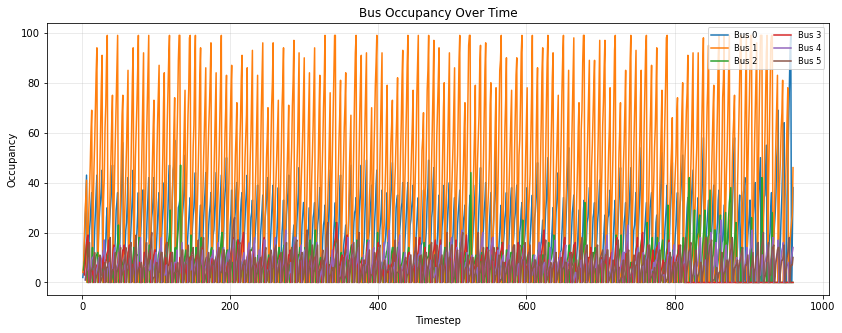

AttributeError: 'list' object has no attribute 'keys'

<Figure size 1008x432 with 0 Axes>

In [23]:
gym.register(
    id='gymnasium_env/BusRouting-v0',
    entry_point=BusEnv,
)

env = gym.make('gymnasium_env/BusRouting-v0')
agent = load_agent(env, MODEL_PATH)

logs, stop_crowding, bus_occupancy = run_episode(env, agent)
env.close()

save_logs(logs)
plot_bus_occupancy(bus_occupancy)
plot_stop_crowding(stop_crowding)